# Imports

In [48]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree as tr
from sklearn import metrics as mt

from sklearn.metrics import auc
from sklearn.metrics import roc_curve, roc_auc_score

In [6]:
# Dataset
# Carregando dados de treinamento/classificação
X_train =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_treinamento/X_training.csv')
y_train =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_treinamento/y_training.csv')

# Carregando dados de validação/classificação
X_val =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_validacao/X_validation.csv')
y_val =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_validacao/y_validation.csv')

# Carregando dados de teste/Classificação
X_test =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_teste/X_test.csv')
y_test =pd.read_csv('/home/alvaro/Documentos/alvaro/comunidadeds/projetos/ensaios_ml/dataset/ensaio_de_classificacao/dados_teste/y_test.csv')


In [7]:
X_train.head()

,id,customer_type,age,class,flight_distance,inflight_wifi_service,departure_arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,...,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,gender_Female,gender_Male,type_of_travel_business_travel,type_of_travel_personal_travel
0,13508,1,0.500000,0.0,0.039580,0.6,0.6,0.6,0.6,1.0,...,0.5,1.00,0.6,0.4,0.000000,0.013848,1.0,0.0,1.0,0.0
1,28874,1,0.243590,0.0,0.205775,0.6,0.4,0.4,0.4,0.6,...,0.5,0.50,0.2,0.6,0.000000,0.000000,0.0,1.0,1.0,0.0
2,21484,0,0.435897,1.0,0.026858,0.6,0.6,0.6,0.2,1.0,...,0.0,1.00,0.6,1.0,0.000000,0.000000,1.0,0.0,1.0,0.0
3,48280,1,0.589744,0.5,0.041397,0.6,1.0,0.6,0.6,0.8,...,0.0,1.00,0.4,0.4,0.029499,0.020772,1.0,0.0,0.0,1.0
4,472,0,0.423077,1.0,0.016559,0.2,0.2,0.2,0.8,0.6,...,1.0,0.75,0.8,0.6,0.021632,0.019782,0.0,1.0,1.0,0.0


# Training

In [8]:
# Algoritmos: 
# Linear Regression, Decision Tree Regressor, Random Forest Regressor, 
# Polinomial Regression, Linear Regression Lasso, Linear Regression Ridge, Linear Regression Elastic Net,
# Polinomial Regression Lasso, Polinomial Regression Ridge e Polinomial Regression Elastic Net
# Métricas de performance: R2, MSE, RMSE, MAE e MAPE

## Linear Regression

In [9]:
# Model Training
lr_model = LinearRegression()
lr_model.fit( X_train, y_train )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
#Modelo validado, agora vamos treinar o modelo com os dados de treinamento e validação juntos para depois testar com os dados de teste
#  Model Training
model_last_lr = LinearRegression()
model_last_lr.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
# Model Performance do treinamento para comparação com o teste
#Previsão sobre os dados de treinamento
y_pred_train = lr_model.predict( X_train )
# # R²
r2_squared_train = mt.r2_score(y_train, y_pred_train)
print("R²:", r2_squared_train)
# MSE 
mse_train = mt.mean_squared_error(y_train, y_pred_train)
print("MSE", mse_train)
# RMSE
rmse_train = np.sqrt(mse_train)
print("RMSE", rmse_train)
# MAE
mae_train = mt.mean_absolute_error(y_train, y_pred_train)
print("MAE", mae_train)
# MAPE
mape_train = mt.mean_absolute_percentage_error(y_train, y_pred_train)
print("MAPE", mape_train)

R²: 0.553549636106226
MSE 0.1096323327773033
RMSE 0.3311077359067639
MAE 0.24902069470379487
MAPE 600767746282241.6


In [12]:
# Model Performance da validação para comparação com o teste
#Previsão sobre os dados de validação
y_pred_val = model_last_lr.predict( X_val )
# # R²
r2_squared_val = mt.r2_score(y_val, y_pred_val)
print("R²:", r2_squared_val)
# MSE 
mse_val = mt.mean_squared_error(y_val, y_pred_val)
print("MSE", mse_val)
# RMSE
rmse_val = np.sqrt(mse_val)
print("RMSE", rmse_val)
# MAE
mae_val = mt.mean_absolute_error(y_val, y_pred_val)
print("MAE", mae_val)
# MAPE
mape_val = mt.mean_absolute_percentage_error(y_val, y_pred_val)
print("MAPE", mape_val)

R²: 0.5480415964878724
MSE 0.1109836750855454
RMSE 0.3331421244537313
MAE 0.24985273184159523
MAPE 599675841541867.4


/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [13]:
# Model Performance validada com os dados de teste e treinada com os dados de treinamento e validação juntos
#Previsão sobre os dados de teste
y_pred_test = model_last_lr.predict( X_test )
# # R²
r2_squared_test = mt.r2_score(y_test, y_pred_test)
print("R²:", r2_squared_test)
# MSE 
mse_test = mt.mean_squared_error(y_test, y_pred_test)
print("MSE", mse_test)
# RMSE
rmse_test = np.sqrt(mse_test)
print("RMSE", rmse_test)
# MAE
mae_test = mt.mean_absolute_error(y_test, y_pred_test)
print("MAE", mae_test)
# MAPE
mape_test = mt.mean_absolute_percentage_error(y_test, y_pred_test)
print("MAPE", mape_test)

R²: 0.5495195462189956
MSE 0.11093957055194692
RMSE 0.3330759231045482
MAE 0.24996953954986162
MAPE 595271467459022.2


/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


## Decision Tree Regressor

In [14]:
# Instanciando e treinando a Decision Tree Regressor
model_train_dt = tr.DecisionTreeRegressor(max_depth=30)
model_train_dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [15]:
#Modelo validado, agora vamos treinar o modelo com os dados de treinamento e validação juntos para depois testar com os dados de teste
#  Model Training
model_last_dt = tr.DecisionTreeRegressor(max_depth=30)
model_last_dt.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_l

In [26]:
# Model Performance do treinamento para comparação com os dados de treinamento
#Previsão sobre os dados de treinamento
y_pred_train_dt = model_train_dt.predict( X_train )
# # R²
r2_squared_train_dt = mt.r2_score(y_train, y_pred_train_dt)
print("R²:", r2_squared_train_dt)
# MSE 
mse_train_dt = mt.mean_squared_error(y_train, y_pred_train_dt)
print("MSE", mse_train_dt)
# RMSE
rmse_train_dt = np.sqrt(mse_train_dt)
print("RMSE", rmse_train_dt)
# MAE
mae_train_dt = mt.mean_absolute_error(y_train, y_pred_train_dt)
print("MAE", mae_train_dt)
# MAPE
mape_train_dt = mt.mean_absolute_percentage_error(y_train, y_pred_train_dt)
print("MAPE", mape_train_dt)

R²: 0.9996766940621913
MSE 7.939244097280364e-05
RMSE 0.00891024359783747
MAE 0.0001587848819456073
MAPE 357551767581.1527


In [17]:
# Model Performance da validação para comparação com os dados de treinamento
#Previsão sobre os dados de validação
y_pred_val_dt = model_last_dt.predict( X_val )
# # R²
r2_squared_val_dt = mt.r2_score(y_val, y_pred_val_dt)
print("R²:", r2_squared_val_dt)
# MSE 
mse_val_dt = mt.mean_squared_error(y_val, y_pred_val_dt)
print("MSE", mse_val_dt)
# RMSE
rmse_val_dt= np.sqrt(mse_val_dt)
print("RMSE", rmse_val_dt)
# MAE
mae_val_dt = mt.mean_absolute_error(y_val, y_pred_val_dt)
print("MAE", mae_val_dt)
# MAPE
mape_val_dt = mt.mean_absolute_percentage_error(y_val, y_pred_val_dt)
print("MAPE", mape_val_dt)

R²: 0.9987222368083017
MSE 0.0003137697049146744
RMSE 0.017713545802991403
MAE 0.0006322064819904127
MAPE 1452791210820.2834


/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


In [27]:
# Model Performance da validação para comparação com os dados de teste
#Previsão sobre os dados de teste
y_pred_test_dt = model_last_dt.predict( X_test )
# # R²
r2_squared_test_dt = mt.r2_score(y_test, y_pred_test_dt)
print("R²:", r2_squared_test_dt)
# MSE 
mse_test_dt = mt.mean_squared_error(y_test, y_pred_test_dt)
print("MSE", mse_test_dt)
# RMSE
rmse_test_dt= np.sqrt(mse_test_dt)
print("RMSE", rmse_test_dt)
# MAE
mae_test_dt = mt.mean_absolute_error(y_test, y_pred_test_dt)
print("MAE", mae_test_dt)
# MAPE
mape_test_dt = mt.mean_absolute_percentage_error(y_test, y_pred_test_dt)
print("MAPE", mape_test_dt)

R²: 0.7881997267662149
MSE 0.052159935371499926
RMSE 0.22838549728802818
MAE 0.05249865254084121
MAPE 119248069936728.4


/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


## Random Forest Regressor

In [33]:
#Instanciando e treinando a Random Forest Regressor
model_train_rf = RandomForestRegressor(n_estimators=100, max_depth=30)
model_train_rf.fit(X_train, y_train)

/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [52]:
#Modelo validado, agora vamos treinar o modelo com os dados de treinamento e validação juntos para depois testar com os dados de teste
#  Model Training
model_last_rf = RandomForestRegressor(n_estimators=50, max_depth=30)
model_last_rf.fit( np.concatenate( (X_train, X_val) ), np.concatenate((y_train, y_val)) )

/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [53]:
# Model Performance do treinamento para comparação com o teste
#Previsão sobre os dados de treinamento
y_pred_train_rf = model_train_rf.predict( X_train )
# # R²
r2_squared_train_rf = mt.r2_score(y_train, y_pred_train_rf)
print("R²:", r2_squared_train_rf)
# MSE 
mse_train_rf = mt.mean_squared_error(y_train, y_pred_train_rf)
print("MSE", mse_train_rf)
# RMSE
rmse_train_rf = np.sqrt(mse_train_rf)
print("RMSE", rmse_train_rf)
# MAE
mae_train_rf = mt.mean_absolute_error(y_train, y_pred_train_rf)
print("MAE", mae_train_rf)
# MAPE
mape_train_rf = mt.mean_absolute_percentage_error(y_train, y_pred_train_rf)
print("MAPE", mape_train_rf)

R²: 0.9836804591249296
MSE 0.004007498886067034
RMSE 0.0633048093438961
MAE 0.021920124383595106
MAPE 50763902740096.85


In [54]:
# Model Performance do treinamento para comparação com o teste
#Previsão sobre os dados de treinamento
y_pred_val_rf = model_last_rf.predict( X_val )
# # R²
r2_squared_val_rf = mt.r2_score(y_val, y_pred_val_rf)
print("R²:", r2_squared_val_rf)
# MSE 
mse_val_rf = mt.mean_squared_error(y_val, y_pred_val_rf)
print("MSE", mse_val_rf)
# RMSE
rmse_val_rf = np.sqrt(mse_val_rf)
print("RMSE", rmse_val_rf)
# MAE
mae_val_rf = mt.mean_absolute_error(y_val, y_pred_val_rf)
print("MAE", mae_val_rf)
# MAPE
mape_val_rf = mt.mean_absolute_percentage_error(y_val, y_pred_val_rf)
print("MAPE", mape_val_rf)

R²: 0.9836034679593475
MSE 0.004026360325172455
RMSE 0.06345360766081354
MAE 0.020969680282898792
MAPE 49394386607568.88


/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [55]:
# Model Performance validada com os dados de teste e treinada com os dados de treinamento e validação juntos
#Previsão sobre os dados de teste
y_pred_test_rf = model_last_rf.predict( X_test )
# # R²
r2_squared_test_rf = mt.r2_score(y_test, y_pred_test_rf)
print("R²:", r2_squared_test_rf)
# MSE 
mse_test_rf = mt.mean_squared_error(y_test, y_pred_test_rf)
print("MSE", mse_test_rf)
# RMSE
rmse_test_rf = np.sqrt(mse_test_rf)
print("RMSE", rmse_test_rf)
# MAE
mae_test_rf = mt.mean_absolute_error(y_test, y_pred_test_rf)
print("MAE", mae_test_rf)
# MAPE
mape_test_rf = mt.mean_absolute_percentage_error(y_test, y_pred_test_rf)
print("MAPE", mape_test_rf)

/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


R²: 0.8874600770980895
MSE 0.027715144157523554
RMSE 0.16647865976612003
MAE 0.05647507309705156
MAPE 133506615310497.28


/home/alvaro/.pyenv/versions/ensaios_ml/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


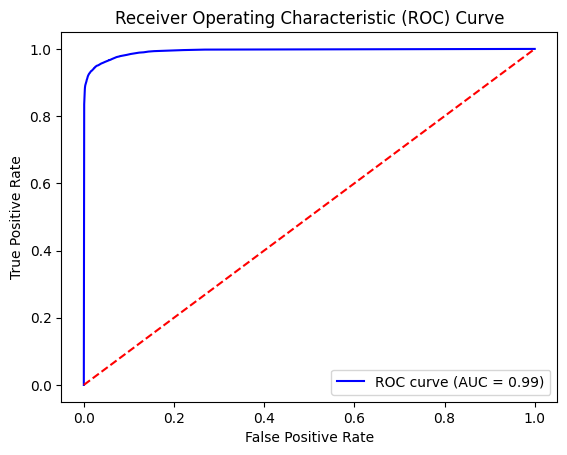

In [56]:
y_scores = model_last_rf.predict(X_test)
y_test_binary = y_test.values.ravel()
fpr, tpr, thresholds = roc_curve(y_test_binary, y_scores)
auc_score = roc_auc_score(y_test_binary, y_scores)
# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
# Calculate AUC score
auc_score = roc_auc_score(y_test, y_scores)
# Plot ROC curve
plt.plot( fpr, tpr, color='b', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='r', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Performance

### Resultados treinamento

In [57]:
# criar tabela com os resultados da performace dos algorítimos de classificação com dados de treinamento
resultados_train = pd.DataFrame(columns=['Nome_do_algoritmo', 'R2', 'MSE', 'RMSE', 'MAE', 'MAPE'])

# adicionar os resultados à tabela
resultados_train.loc[0] = ['Linear Regression', r2_squared_train, mse_train, rmse_train, mae_train, mape_train]
resultados_train.loc[1] = ['Decision Tree Regressor', r2_squared_train_dt, mse_train_dt, rmse_train_dt, mae_train_dt, mape_train_dt]
resultados_train.loc[2] = ['Random Forest Regressor', r2_squared_train_rf, mse_train_rf, rmse_train_rf, mae_train_rf, mape_train_rf]
#resultados_train.loc[3] = ['Polynomial Regression', r2_squared_train_lr, mse_train_lr, rmse_train_lr, mae_train_lr, mape_train_lr]

resultados_train = resultados_train.reset_index(drop=True)
resultados_train

,Nome_do_algoritmo,R2,MSE,RMSE,MAE,MAPE
0,Linear Regression,0.553550,0.109632,0.331108,0.249021,6.007677e+14
1,Decision Tree Regressor,0.999677,0.000079,0.008910,0.000159,3.575518e+11
2,Random Forest Regressor,0.983680,0.004007,0.063305,0.021920,5.076390e+13


### Resultados validação

In [58]:
# criar tabela com os resultados da performace dos algorítimos de classificação com dados de validação
resultados_train = pd.DataFrame(columns=['Nome_do_algoritmo', 'R2', 'MSE', 'RMSE', 'MAE', 'MAPE'])

# adicionar os resultados à tabela
resultados_train.loc[0] = ['Linear Regression', r2_squared_val, mse_val, rmse_val, mae_val, mape_val]
resultados_train.loc[1] = ['Decision Tree Regressor', r2_squared_val_dt, mse_val_dt, rmse_val_dt, mae_val_dt, mape_val_dt]
resultados_train.loc[2] = ['Random Forest Regressor', r2_squared_val_rf, mse_val_rf, rmse_val_rf, mae_val_rf, mape_val_rf]
#resultados_train.loc[3] = ['Polynomial Regression', r2_squared_val_lr, mse_val_lr, rmse_val_lr, mae_val_lr, mape_val_lr]

resultados_train = resultados_train.reset_index(drop=True)
resultados_train

,Nome_do_algoritmo,R2,MSE,RMSE,MAE,MAPE
0,Linear Regression,0.548042,0.110984,0.333142,0.249853,5.996758e+14
1,Decision Tree Regressor,0.998722,0.000314,0.017714,0.000632,1.452791e+12
2,Random Forest Regressor,0.983603,0.004026,0.063454,0.020970,4.939439e+13


## Resultados Teste

In [59]:
# criar tabela com os resultados da performace dos algorítimos de classificação com dados de teste
resultados_train = pd.DataFrame(columns=['Nome_do_algoritmo', 'R2', 'MSE', 'RMSE', 'MAE', 'MAPE'])

# adicionar os resultados à tabela
resultados_train.loc[0] = ['Linear Regression', r2_squared_test, mse_test, rmse_test, mae_test, mape_test]
resultados_train.loc[1] = ['Decision Tree Regressor', r2_squared_test_dt, mse_test_dt, rmse_test_dt, mae_test_dt, mape_test_dt]
resultados_train.loc[2] = ['Random Forest Regressor', r2_squared_test_rf, mse_test_rf, rmse_test_rf, mae_test_rf, mape_test_rf]
#resultados_train.loc[3] = ['Polynomial Regression', r2_squared_lr, mse_lr, rmse_lr, mae_lr, mape_lr]

resultados_train = resultados_train.reset_index(drop=True)
resultados_train

,Nome_do_algoritmo,R2,MSE,RMSE,MAE,MAPE
0,Linear Regression,0.54952,0.110940,0.333076,0.249970,5.952715e+14
1,Decision Tree Regressor,0.78820,0.052160,0.228385,0.052499,1.192481e+14
2,Random Forest Regressor,0.88746,0.027715,0.166479,0.056475,1.335066e+14
